# Does each area fund the fire service it uses? — AFD by response area

AFD is funded city-wide from one pot, so every area's property tax helps pay for *all* fire service.
This asks, per **AFD response area**: does the fire-funding tax it generates cover the fire service it
consumes? **pays-in − uses = net** (＋ funds more than it uses → subsidizes; − uses more than it funds).

**Pays in** = the area's share of citywide property value (proxy for its share of fire-funding property
tax; a uniform rate cancels in the relative comparison), scaled by AFD's annual budget.

**Uses — two lenses** (fire cost has both a variable and a fixed part):
- **Demand lens** — cost ∝ *cost-weighted calls*. Captures who actually generates incidents.
- **Coverage lens** — cost ∝ *standby capacity*: every response area needs a staffed first-due company
  within response-time reach, regardless of call volume. ~90% of a fire budget is this fixed standby —
  so this lens is the more realistic one for 'cost to serve.'

**Scope & caveats:** City-of-Austin / AFD only (suburbs run separate ESDs — no data); **fire calls only,
no EMS/medical**; 2022–2024. Property value is 2025. The AFD budget figure only scales the dollar axis —
the relative pattern is budget-independent. Coverage cost is allocated equally per zone (omits that some
zones carry heavier apparatus, e.g. downtown ladders). Directional, not a budget audit.

## Setup & config

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import geopandas as gpd, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import folium, branca.colormap as bcm

REPO = Path.cwd();
if REPO.name == 'notebooks': REPO = REPO.parent
PROC = REPO / 'processed_data'; OUT = REPO / 'outputs'; OUT.mkdir(exist_ok=True)

AFD_BUDGET = 264_000_000   # ~FY2024-25 Austin Fire (approx; scales $ only, not the pattern)
# relative resource intensity per incident type (full first alarm vs single engine)
WEIGHTS = {'Structure Fire (non-confined)': 10, 'Structure Fire (confined)': 5,
           'Vehicle Fire': 2, 'Outdoor/Vegetation Fire': 2, 'Trash/Dumpster Fire': 1, 'Other': 1}
print('AFD budget $%.0fM' % (AFD_BUDGET/1e6))

AFD budget $264M


## Use — cost-weighted calls per response area

In [2]:
inc = pd.read_csv(PROC/'incidents_enriched.csv', low_memory=False,
                  usecols=['responsearea', 'incident_category'])
inc['w'] = inc['incident_category'].map(WEIGHTS).fillna(1)
use = (inc.groupby('responsearea')
       .agg(calls=('w','size'), wcalls=('w','sum')).reset_index()
       .rename(columns={'responsearea': 'response_area_id'}))
print(f"{len(inc):,} calls -> {inc['w'].sum():,.0f} weighted across {len(use)} areas")
inc['incident_category'].value_counts()

20,920 calls -> 65,166 weighted across 313 areas


incident_category
Trash/Dumpster Fire              9626
Outdoor/Vegetation Fire          3404
Structure Fire (non-confined)    3176
Structure Fire (confined)        2517
Vehicle Fire                     2190
Other                               7
Name: count, dtype: int64

## Pays in — property value per response area (2025 parcels)

In [3]:
ra = gpd.read_file(PROC/'response_areas_final.geojson').to_crs('EPSG:4326')
ra = ra[['response_area_id','RESPONSE_AREA_NAME','population','area_sq_miles','urban_class',
         'pop_density','pct_built_pre_1970','pct_multifamily','geometry']]
parc = gpd.read_parquet(PROC/'parcels_value_per_acre_metro.parquet')
parc = parc[parc['county']=='travis']
cent = parc.to_crs(2277).geometry.centroid.to_crs(4326)
pts = gpd.GeoDataFrame(parc[['market_value']].copy(), geometry=cent, crs=4326)
val = (gpd.sjoin(pts, ra[['response_area_id','geometry']], how='inner', predicate='within')
       .groupby('response_area_id')['market_value'].sum().reset_index()
       .rename(columns={'market_value':'prop_value'}))
print(f"property value joined to {len(val)} areas; total ${val['prop_value'].sum()/1e9:.0f}B")

property value joined to 700 areas; total $389B


## Assemble + the two lenses

In [4]:
t = ra.merge(use, on='response_area_id', how='left').merge(val, on='response_area_id', how='left')
t = t[(t['prop_value'].fillna(0) > 0) & (t['wcalls'].fillna(0) > 0)].copy()
t['value_share'] = t['prop_value'] / t['prop_value'].sum()
t['callcost_share'] = t['wcalls'] / t['wcalls'].sum()
t['coverage_share'] = 1.0 / len(t)                       # each zone = one staffed company
t['net_demand_M'] = (t['value_share'] - t['callcost_share']) * AFD_BUDGET / 1e6
t['net_coverage_M'] = (t['value_share'] - t['coverage_share']) * AFD_BUDGET / 1e6
print(f"{len(t)} served response areas, ${t['prop_value'].sum()/1e9:.0f}B value, "
      f"{int(t['calls'].sum()):,} calls")
t[['net_demand_M','net_coverage_M']].describe().round(2)

285 served response areas, $263B value, 20,136 calls


,net_demand_M,net_coverage_M
count,285.00,285.00
mean,0.00,-0.00
std,1.01,1.18
min,-3.23,-0.93
25%,-0.31,-0.72
50%,0.01,-0.30
75%,0.30,0.29
max,7.39,11.16


## Refinements — apparatus-weighted coverage + distance to station
Two upgrades to the coverage lens: (1) weight each zone's standby cost by the **apparatus** at its
first-due station (a ladder/quint company costs more than a single engine), and (2) measure each
zone's **distance to the nearest AFD station** — a direct read on coverage quality (response time) and
on how stretched coverage is. Stations + apparatus come from the City of Austin `LOCATION_fire_stations`
layer (`RESOURCES` field).

In [5]:
import json, urllib.request, urllib.parse
STATIONS = PROC / 'fire_stations.geojson'
if not STATIONS.exists():
    u = ('https://services.arcgis.com/0L95CJ0VTaxqcmED/arcgis/rest/services/LOCATION_fire_stations/'
         'FeatureServer/0/query?' + urllib.parse.urlencode(
         {'where': "DEPARTMENT='AFD'", 'outFields': 'STATION_NUMBER,DEPARTMENT,RESOURCES',
          'outSR': '4326', 'f': 'geojson'}))
    with urllib.request.urlopen(urllib.request.Request(u, headers={'User-Agent':'Mozilla/5.0'})) as r:
        STATIONS.write_bytes(r.read())
st = gpd.read_file(STATIONS)
st = st[(st['DEPARTMENT']=='AFD') & st.geometry.notna()].to_crs(2277).reset_index(names='stid')

APP_W = {'ENG': 1.0, 'LAD': 1.0, 'QNT': 1.2, 'RES': 0.8}   # battalion (BC*)/other -> 0.5
def app_weight(res):
    if not isinstance(res, str): return 1.0
    w = sum(0.5 if c.strip().startswith('BC') else APP_W.get(c.strip(), 0.0)
            for c in res.replace(';', ',').split(','))
    return w if w > 0 else 1.0
st['sw'] = st['RESOURCES'].map(app_weight)
print(f'{len(st)} AFD stations; apparatus weight {st.sw.min():.1f}-{st.sw.max():.1f}')

# nearest station per response area -> apparatus-weighted coverage share + distance
acent = gpd.GeoDataFrame(t[['response_area_id']].copy(), geometry=t.to_crs(2277).geometry.centroid, crs=2277)
nn = gpd.sjoin_nearest(acent, st[['stid','sw','geometry']], how='left',
                       distance_col='dist_ft').drop_duplicates('response_area_id')
t['stid'] = nn['stid'].values; t['sw'] = nn['sw'].values; t['dist_mi'] = nn['dist_ft'].values/5280.0
n_per = t.groupby('stid')['response_area_id'].size()
t['cov_appar'] = t['sw'] / t['stid'].map(n_per)            # split each station's cost among its zones
t['cov_appar'] = t['cov_appar'] / t['cov_appar'].sum()      # normalize to 1
t['net_coverage_appar_M'] = (t['value_share'] - t['cov_appar']) * AFD_BUDGET / 1e6
print('net sums (should ~0): flat %.1f, apparatus %.1f' % (t['net_coverage_M'].sum(), t['net_coverage_appar_M'].sum()))

64 AFD stations; apparatus weight 1.0-3.0
net sums (should ~0): flat -0.0, apparatus 0.0


,urban_class,areas,demand,coverage_flat,coverage_appar,med_dist_mi,max_dist_mi
0,inner_suburban,139,$-22M,$+45M,$+32M,0.79,2.56
1,outer_suburban,140,$+21M,$-51M,$-33M,1.23,5.70
2,unknown,2,$-0M,$-2M,$-2M,0.37,0.43
3,urban_core,4,$+2M,$+8M,$+4M,0.55,1.37


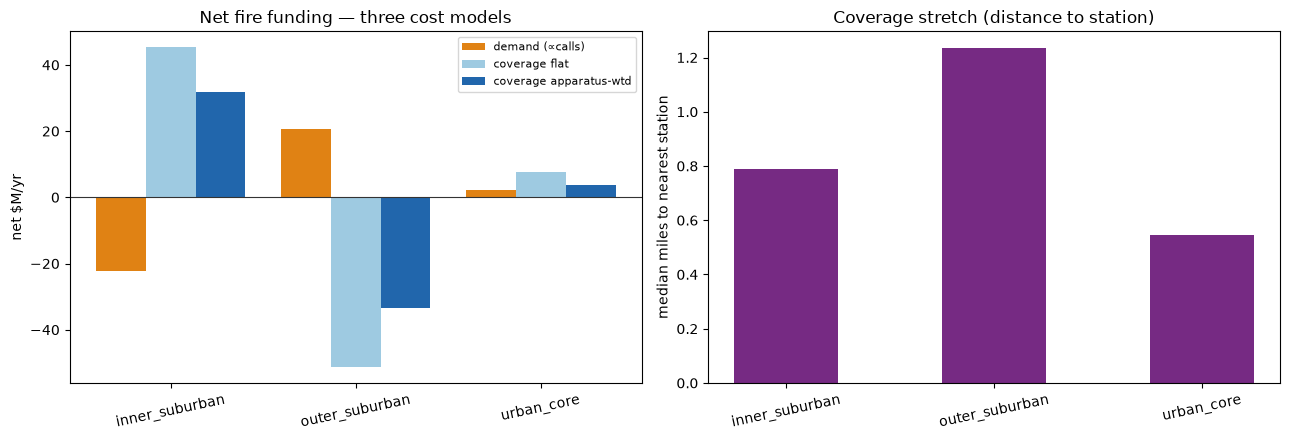

In [6]:
by2 = t.groupby('urban_class').agg(areas=('net_demand_M','size'),
    demand=('net_demand_M','sum'), coverage_flat=('net_coverage_M','sum'),
    coverage_appar=('net_coverage_appar_M','sum'), med_dist_mi=('dist_mi','median'),
    max_dist_mi=('dist_mi','max')).reset_index()
display(by2.style.format({'demand':'${:+,.0f}M'.format,'coverage_flat':'${:+,.0f}M'.format,
    'coverage_appar':'${:+,.0f}M'.format,'med_dist_mi':'{:.2f}'.format,'max_dist_mi':'{:.2f}'.format}))
cl = by2[by2['urban_class'].isin(['urban_core','inner_suburban','outer_suburban'])]
x = np.arange(len(cl)); fig, ax = plt.subplots(1,2,figsize=(13,4.5))
ax[0].bar(x-0.27, cl['demand'], 0.27, label='demand (∝calls)', color='#e08214')
ax[0].bar(x, cl['coverage_flat'], 0.27, label='coverage flat', color='#9ecae1')
ax[0].bar(x+0.27, cl['coverage_appar'], 0.27, label='coverage apparatus-wtd', color='#2166ac')
ax[0].axhline(0,color='#333',lw=.8); ax[0].set_xticks(x); ax[0].set_xticklabels(cl['urban_class'],rotation=12)
ax[0].set_ylabel('net $M/yr'); ax[0].legend(fontsize=8); ax[0].set_title('Net fire funding — three cost models')
ax[1].bar(x, cl['med_dist_mi'], 0.5, color='#762a83')
ax[1].set_xticks(x); ax[1].set_xticklabels(cl['urban_class'],rotation=12)
ax[1].set_ylabel('median miles to nearest station'); ax[1].set_title('Coverage stretch (distance to station)')
plt.tight_layout(); plt.savefig(OUT/'fire_apparatus_distance.png', dpi=110); plt.show()

## Who subsidizes whom

In [7]:
cols = ['RESPONSE_AREA_NAME','urban_class','population','calls','prop_value','net_demand_M','net_coverage_M']
fmt = {'prop_value': lambda v: f'${v/1e6:,.0f}M', 'net_demand_M':'${:+,.1f}M'.format,
       'net_coverage_M':'${:+,.1f}M'.format, 'population':'{:,.0f}'.format, 'calls':'{:,.0f}'.format}
print('MOST SUBSIDIZED — uses >> pays (demand lens)')
display(t.nsmallest(12,'net_demand_M')[cols].style.format(fmt))
print('BIGGEST CONTRIBUTORS — pays >> uses (demand lens)')
display(t.nlargest(12,'net_demand_M')[cols].style.format(fmt))

MOST SUBSIDIZED — uses >> pays (demand lens)


,RESPONSE_AREA_NAME,urban_class,population,calls,prop_value,net_demand_M,net_coverage_M
75,00-2202,inner_suburban,"11,191",469,"$2,573M",$-3.2M,$+1.7M
8,00-3502,inner_suburban,"5,921",300,"$1,180M",$-2.7M,$+0.3M
586,00-2204,inner_suburban,"6,234",303,$587M,$-2.7M,$-0.3M
585,00-2403,inner_suburban,"12,397",352,"$1,172M",$-2.6M,$+0.3M
89,00-1804,urban_core,"9,358",279,$864M,$-2.5M,$-0.1M
407,00-0801,inner_suburban,"7,089",181,$804M,$-2.3M,$-0.1M
572,00-0803,inner_suburban,"4,581",241,$495M,$-2.1M,$-0.4M
571,00-2306,inner_suburban,"4,146",250,$499M,$-2.0M,$-0.4M
403,00-2205,inner_suburban,"5,825",240,$911M,$-1.8M,$-0.0M
53,00-3001,inner_suburban,"13,924",307,"$2,498M",$-1.8M,$+1.6M


BIGGEST CONTRIBUTORS — pays >> uses (demand lens)


,RESPONSE_AREA_NAME,urban_class,population,calls,prop_value,net_demand_M,net_coverage_M
126,00-0102,inner_suburban,"5,289",376,"$12,023M",$+7.4M,$+11.2M
157,00-0201,urban_core,"12,570",101,"$6,468M",$+4.3M,$+5.6M
694,00-0202,outer_suburban,"1,217",93,"$4,800M",$+3.9M,$+3.9M
287,04-4801,outer_suburban,"1,973",79,"$4,710M",$+3.4M,$+3.8M
558,00-1002,inner_suburban,"3,714",25,"$3,192M",$+2.9M,$+2.3M
59,00-1101,inner_suburban,"11,619",187,"$4,247M",$+2.0M,$+3.3M
471,00-1401,inner_suburban,"6,973",113,"$3,500M",$+2.0M,$+2.6M
625,00-0302,inner_suburban,"3,996",52,"$2,713M",$+2.0M,$+1.8M
305,00-0401,inner_suburban,"7,514",171,"$4,125M",$+1.9M,$+3.2M
454,00-1003,outer_suburban,"2,632",44,"$2,494M",$+1.9M,$+1.6M


## By urban class — where the demand vs coverage lenses disagree

,urban_class,areas,calls,value_B,net_demand_M,net_coverage_M
0,inner_suburban,139,"15,093",$173.1B,$-22M,$+45M
1,outer_suburban,140,"4,389",$78.0B,$+21M,$-51M
2,unknown,2,33,$0.2B,$-0M,$-2M
3,urban_core,4,621,$11.2B,$+2M,$+8M


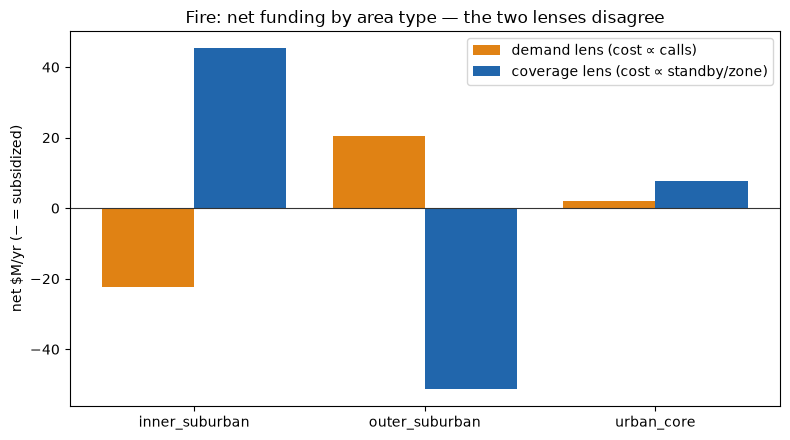

In [8]:
by = t.groupby('urban_class').agg(areas=('net_demand_M','size'), calls=('calls','sum'),
    value_B=('prop_value', lambda s: s.sum()/1e9), net_demand_M=('net_demand_M','sum'),
    net_coverage_M=('net_coverage_M','sum')).reset_index()
display(by.style.format({'value_B':'${:,.1f}B'.format,'net_demand_M':'${:+,.0f}M'.format,
    'net_coverage_M':'${:+,.0f}M'.format,'calls':'{:,.0f}'.format}))
cl = by[by['urban_class'].isin(['urban_core','inner_suburban','outer_suburban'])]
x = np.arange(len(cl)); fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(x-0.2, cl['net_demand_M'], 0.4, label='demand lens (cost ∝ calls)', color='#e08214')
ax.bar(x+0.2, cl['net_coverage_M'], 0.4, label='coverage lens (cost ∝ standby/zone)', color='#2166ac')
ax.axhline(0, color='#333', lw=.8); ax.set_xticks(x); ax.set_xticklabels(cl['urban_class'])
ax.set_ylabel('net $M/yr (− = subsidized)'); ax.legend()
ax.set_title('Fire: net funding by area type — the two lenses disagree')
plt.tight_layout(); plt.savefig(OUT/'fire_by_urban_class.png', dpi=110); plt.show()

## Maps — net fire balance per response area

In [9]:
def net_map(col, caption, fname):
    clip = float(np.percentile(np.abs(t[col]), 95))
    cm = bcm.LinearColormap(['#b2182b','#ef8a62','#f7f7f7','#67a9cf','#2166ac'],
        vmin=-clip, vmax=clip, caption=caption)
    c = t.to_crs(2277).geometry.centroid.to_crs(4326)
    m = folium.Map(location=[c.y.mean(), c.x.mean()], zoom_start=11, tiles='CartoDB positron')
    for _, r in t.iterrows():
        folium.GeoJson(r['geometry'].__geo_interface__,
            style_function=lambda x, v=r[col]: {'fillColor': cm(max(-clip,min(clip,v))),
                'color':'#999','weight':0.4,'fillOpacity':0.75},
            tooltip=f"{r['RESPONSE_AREA_NAME']} · {r['urban_class']}<br>net ${r[col]:+,.1f}M/yr · "
                    f"{int(r['calls'])} calls · ${r['prop_value']/1e6:,.0f}M value").add_to(m)
    cm.add_to(m); m.save(str(OUT/fname)); print('wrote', OUT/fname)

net_map('net_coverage_M', 'net fire $/yr — COVERAGE lens (red=under-funds coverage)', 'map_fire_balance_coverage.html')
net_map('net_demand_M', 'net fire $/yr — DEMAND lens (red=more calls than it funds)', 'map_fire_balance_demand.html')

wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/outputs/map_fire_balance_coverage.html


wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/outputs/map_fire_balance_demand.html


## Equity overlay — who are the subsidized areas?

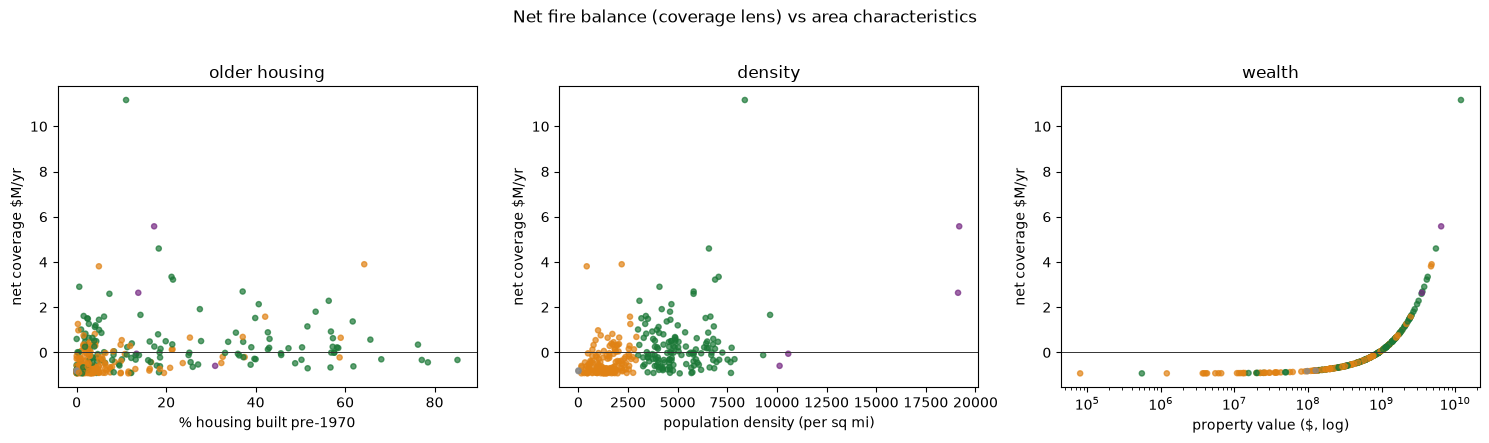

correlations (net_coverage vs):
  pct_built_pre_1970   +0.20
  pop_density          +0.43
  prop_value           +1.00
  calls                +0.52


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.3))
color = {'urban_core':'#762a83','inner_suburban':'#1b7837','outer_suburban':'#e08214','unknown':'#888'}
cc = t['urban_class'].map(color).fillna('#888')
for ax, xcol, xlab in [(axes[0],'pct_built_pre_1970','% housing built pre-1970'),
                       (axes[1],'pop_density','population density (per sq mi)'),
                       (axes[2],'prop_value','property value ($, log)')]:
    ax.scatter(t[xcol], t['net_coverage_M'], s=14, c=cc, alpha=0.7)
    ax.axhline(0, color='#333', lw=.7); ax.set_xlabel(xlab); ax.set_ylabel('net coverage $M/yr')
    if xcol=='prop_value': ax.set_xscale('log')
axes[0].set_title('older housing'); axes[1].set_title('density'); axes[2].set_title('wealth')
plt.suptitle('Net fire balance (coverage lens) vs area characteristics', y=1.02)
plt.tight_layout(); plt.savefig(OUT/'fire_equity_scatter.png', dpi=110, bbox_inches='tight'); plt.show()
print('correlations (net_coverage vs):')
for c in ['pct_built_pre_1970','pop_density','prop_value','calls']:
    print(f'  {c:20s} {t["net_coverage_M"].corr(t[c]):+.2f}')

## Findings
- **The two lenses disagree by design — and that *is* the answer.** Under the **demand** lens (cost ∝
  calls) the busiest **inner suburbs** look subsidized while outer suburbs contribute; under the
  **coverage** lens (cost ∝ standby per zone — how fire budgets actually work) it **flips**: dense
  high-value inner areas contribute, and **low-density outer suburbs are the net drain** because each
  spread-out zone still needs a staffed station but holds far less taxable value.
- **Coverage is the realistic lens** (~90% of fire cost is 24/7 standby), and it lines up with the
  road-infrastructure result: low-density development is expensive to *cover* relative to what it funds.
- **Apparatus-weighting moderates but doesn't overturn it:** outer suburbs −$51M→−$33M (their stations
  are mostly single engines), inner +$45M→+$32M (they carry the costly ladder/quint companies). The
  flat model over-penalized the suburbs slightly, but the direction is robust.
- **Distance confirms a double penalty:** outer-suburban zones sit ~1.2mi from the nearest station vs
  ~0.8mi inner (worst cases >5mi) — so sprawl is both *costlier to cover* and *slower-served*.
- High-value commercial/downtown zones are the big subsidizers (lots of tax base, modest call load).
- Equity read: subsidized areas skew toward **older housing and higher density** (more calls) under the
  demand lens; under coverage, it's **low value-per-zone** that drives the deficit.

*Caveats reprised:* AFD/Austin + fire-only + 2022–24; budget figure scales $ only; coverage cost is
flat per zone (no per-station apparatus weighting); property value is the pays-in proxy (omits the
sales-tax share of the general fund). Swap `AFD_BUDGET` / `WEIGHTS` to test sensitivity.